In [124]:
import pandas as pd 
import numpy as np



In [125]:
!python -m pip install openpyxl




[notice] A new release of pip is available: 25.1.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [126]:

bbdd_bank= pd.read_csv("C:/Users/Usuario/Desktop/the Power data analytics/Pandas_proyecto/bank-additional.csv", index_col= 0)
bbdd_bank.columns




Index(['age', 'job', 'marital', 'education', 'default', 'housing', 'loan',
       'contact', 'duration', 'campaign', 'pdays', 'previous', 'poutcome',
       'emp.var.rate', 'cons.price.idx', 'cons.conf.idx', 'euribor3m',
       'nr.employed', 'y', 'date', 'latitude', 'longitude', 'id_'],
      dtype='object')

In [127]:
bbdd_bank.head(43001)

,age,job,marital,education,default,housing,loan,contact,duration,campaign,...,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y,date,latitude,longitude,id_
0,NaN,housemaid,MARRIED,basic.4y,0.0,0.0,0.0,telephone,261,1,...,1.1,"93,994","-36,4","4,857",5191,no,2-agosto-2019,41.495,-71.233,089b39d8-e4d0-461b-87d4-814d71e0e079
1,57.0,services,MARRIED,high.school,NaN,0.0,0.0,telephone,149,1,...,1.1,"93,994","-36,4",NaN,5191,no,14-septiembre-2016,34.601,-83.923,e9d37224-cb6f-4942-98d7-46672963d097
2,37.0,services,MARRIED,high.school,0.0,1.0,0.0,telephone,226,1,...,1.1,"93,994","-36,4","4,857",5191,no,15-febrero-2019,34.939,-94.847,3f9f49b5-e410-4948-bf6e-f9244f04918b
3,40.0,admin.,MARRIED,basic.6y,0.0,0.0,0.0,telephone,151,1,...,1.1,"93,994","-36,4",NaN,5191,no,29-noviembre-2015,49.041,-70.308,9991fafb-4447-451a-8be2-b0df6098d13e
4,56.0,services,MARRIED,high.school,0.0,0.0,1.0,telephone,307,1,...,1.1,"93,994","-36,4",NaN,5191,no,29-enero-2017,38.033,-104.463,eca60b76-70b6-4077-80ba-bc52e8ebb0eb
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
19154,NaN,admin.,MARRIED,university.degree,0.0,0.0,0.0,cellular,618,2,...,1.4,"93,444","-36,1",NaN,"5228,1",yes,13-octubre-2015,38.147,-105.582,4eed05de-2a98-4227-b488-32122009b638
26206,34.0,technician,MARRIED,professional.course,0.0,1.0,1.0,cellular,42,7,...,-0.1,"93,2",-42,NaN,"5195,8",no,17-marzo-2018,49.235,-112.201,0f0aca88-4088-4fe2-905f-44fb675d9493
15046,NaN,blue-collar,SINGLE,basic.6y,0.0,1.0,0.0,cellular,391,2,...,1.4,"93,918","-42,7",NaN,"5228,1",no,15-septiembre-2016,40.679,-120.015,cadadd4b-7ee5-4019-b13a-ca01bb67ca5b
15280,NaN,admin.,MARRIED,university.degree,NaN,0.0,0.0,cellular,674,3,...,1.4,"93,918","-42,7","4,958","5228,1",no,23-septiembre-2019,27.772,-117.518,5f432048-d515-4bb5-9c94-62db451f88d4


In [128]:
bbdd_bank_1= bbdd_bank.drop("date",axis=1,inplace=False)
bbdd_bank_1.isna().sum()



age               5120
job                345
marital             85
education         1807
default           8981
housing           1026
loan              1026
contact              0
duration             0
campaign             0
pdays                0
previous             0
poutcome             0
emp.var.rate         0
cons.price.idx     471
cons.conf.idx        0
euribor3m         9256
nr.employed          0
y                    0
latitude             0
longitude            0
id_                  0
dtype: int64

In [129]:
bbdd_bank_1.dtypes

age               float64
job                object
marital            object
education          object
default           float64
housing           float64
loan              float64
contact            object
duration            int64
campaign            int64
pdays               int64
previous            int64
poutcome           object
emp.var.rate      float64
cons.price.idx     object
cons.conf.idx      object
euribor3m          object
nr.employed        object
y                  object
latitude          float64
longitude         float64
id_                object
dtype: object

In [130]:
columnas_media=  bbdd_bank_1.select_dtypes(include=["float64", "int64"]).columns

columnas_moda= bbdd_bank_1.select_dtypes(include=["object", "category"]).columns


In [131]:

for col in columnas_media:
    bbdd_bank_1[columnas_media] = bbdd_bank_1[columnas_media].fillna(bbdd_bank_1[columnas_media].median())


for col in columnas_moda:
    bbdd_bank_1[col] = bbdd_bank_1[col].fillna(bbdd_bank_1[col].mode()[0])


In [132]:
bbdd_bank_1.isna().sum()




age               0
job               0
marital           0
education         0
default           0
housing           0
loan              0
contact           0
duration          0
campaign          0
pdays             0
previous          0
poutcome          0
emp.var.rate      0
cons.price.idx    0
cons.conf.idx     0
euribor3m         0
nr.employed       0
y                 0
latitude          0
longitude         0
id_               0
dtype: int64

In [133]:
bbdd_bank_grupos= bbdd_bank_1.groupby("contact")
bbdd_bank_grupos.size()

contact
cellular     27396
telephone    15604
dtype: int64

In [134]:
bbdd_bank_1.drop("contact", axis=1, inplace= True)



In [135]:
bbdd_bank_1

,age,job,marital,education,default,housing,loan,duration,campaign,pdays,...,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y,latitude,longitude,id_
0,38.0,housemaid,MARRIED,basic.4y,0.0,0.0,0.0,261,1,999,...,NONEXISTENT,1.1,"93,994","-36,4","4,857",5191,no,41.495,-71.233,089b39d8-e4d0-461b-87d4-814d71e0e079
1,57.0,services,MARRIED,high.school,0.0,0.0,0.0,149,1,999,...,NONEXISTENT,1.1,"93,994","-36,4","4,857",5191,no,34.601,-83.923,e9d37224-cb6f-4942-98d7-46672963d097
2,37.0,services,MARRIED,high.school,0.0,1.0,0.0,226,1,999,...,NONEXISTENT,1.1,"93,994","-36,4","4,857",5191,no,34.939,-94.847,3f9f49b5-e410-4948-bf6e-f9244f04918b
3,40.0,admin.,MARRIED,basic.6y,0.0,0.0,0.0,151,1,999,...,NONEXISTENT,1.1,"93,994","-36,4","4,857",5191,no,49.041,-70.308,9991fafb-4447-451a-8be2-b0df6098d13e
4,56.0,services,MARRIED,high.school,0.0,0.0,1.0,307,1,999,...,NONEXISTENT,1.1,"93,994","-36,4","4,857",5191,no,38.033,-104.463,eca60b76-70b6-4077-80ba-bc52e8ebb0eb
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
19154,38.0,admin.,MARRIED,university.degree,0.0,0.0,0.0,618,2,999,...,NONEXISTENT,1.4,"93,444","-36,1","4,857","5228,1",yes,38.147,-105.582,4eed05de-2a98-4227-b488-32122009b638
26206,34.0,technician,MARRIED,professional.course,0.0,1.0,1.0,42,7,999,...,NONEXISTENT,-0.1,"93,2",-42,"4,857","5195,8",no,49.235,-112.201,0f0aca88-4088-4fe2-905f-44fb675d9493
15046,38.0,blue-collar,SINGLE,basic.6y,0.0,1.0,0.0,391,2,999,...,NONEXISTENT,1.4,"93,918","-42,7","4,857","5228,1",no,40.679,-120.015,cadadd4b-7ee5-4019-b13a-ca01bb67ca5b
15280,38.0,admin.,MARRIED,university.degree,0.0,0.0,0.0,674,3,999,...,NONEXISTENT,1.4,"93,918","-42,7","4,958","5228,1",no,27.772,-117.518,5f432048-d515-4bb5-9c94-62db451f88d4


In [136]:
bbdd_bank_grupos2= bbdd_bank_1.groupby("poutcome")
bbdd_bank_grupos2.size()

poutcome
FAILURE         4461
NONEXISTENT    37103
SUCCESS         1436
dtype: int64

In [137]:
bbdd_bank_1.drop("poutcome", axis=1, inplace= True)

In [138]:
bbdd_bank_grupos3= bbdd_bank_1.groupby("education")
bbdd_bank_grupos3.size()

education
basic.4y                4356
basic.6y                2386
basic.9y                6309
high.school             9925
illiterate                18
professional.course     5477
university.degree      14529
dtype: int64

In [139]:
bbdd_bank_1.drop("marital", axis=1, inplace= True)


In [140]:
bbdd_customer_detais= pd.read_excel("C:/Users/Usuario/Desktop/the Power data analytics/Pandas_proyecto/customer-details.xlsx", index_col= 0 )
bbdd_customer_detais.head(20114)

,Income,Kidhome,Teenhome,Dt_Customer,NumWebVisitsMonth,ID
0,161770,1,0,2012-04-04,29,089b39d8-e4d0-461b-87d4-814d71e0e079
1,85477,1,1,2012-12-30,7,e9d37224-cb6f-4942-98d7-46672963d097
2,147233,1,1,2012-02-02,5,3f9f49b5-e410-4948-bf6e-f9244f04918b
3,121393,1,2,2012-12-21,29,9991fafb-4447-451a-8be2-b0df6098d13e
4,63164,1,2,2012-06-20,20,eca60b76-70b6-4077-80ba-bc52e8ebb0eb
...,...,...,...,...,...,...
20109,75138,1,0,2012-08-29,12,6f433a73-1a2f-4b3d-8208-ad68248bc913
20110,114469,0,2,2012-10-28,13,25f35a3f-0fd2-4e6a-b4d5-74fa1a1f4cfc
20111,82207,0,1,2012-02-10,27,a3d2d088-3781-44ea-9944-a4a40df51285
20112,135009,0,0,2012-09-14,17,3769cb72-26be-40f2-9a93-f752fc96d628


In [141]:
bbdd_customer_1= pd.read_excel("C:/Users/Usuario/Desktop/the Power data analytics/Pandas_proyecto/customer-details.xlsx", sheet_name="2013" )
bbdd_customer_2= pd.read_excel("C:/Users/Usuario/Desktop/the Power data analytics/Pandas_proyecto/customer-details.xlsx", sheet_name="2014" )
bbdd_customer_3= pd.read_excel("C:/Users/Usuario/Desktop/the Power data analytics/Pandas_proyecto/customer-details.xlsx", sheet_name="2012" )



In [142]:
bbdd_cd_unidas = bbdd_cd_unidas = pd.concat([bbdd_customer_1, bbdd_customer_2, bbdd_customer_3], ignore_index=True)

In [143]:
bbdd_cd_unidas

,Unnamed: 0,Income,Kidhome,Teenhome,Dt_Customer,NumWebVisitsMonth,ID
0,0,82407,0,1,2013-10-07,29,ef81336c-e41a-46d0-8a30-5d4ac3b836be
1,1,24877,0,0,2013-04-21,32,50b224ac-84b4-42a7-aba9-3e1d1d620479
2,2,78839,1,0,2013-11-25,21,9cb15c53-b647-464a-add9-09cdae04897c
3,3,113859,1,1,2013-01-06,12,f8aaf334-949d-4943-a214-b64fe9c088b4
4,4,147317,0,0,2013-07-10,14,885fe85a-3718-4760-a32a-a57628cf7528
...,...,...,...,...,...,...,...
43165,20110,114469,0,2,2012-10-28,13,25f35a3f-0fd2-4e6a-b4d5-74fa1a1f4cfc
43166,20111,82207,0,1,2012-02-10,27,a3d2d088-3781-44ea-9944-a4a40df51285
43167,20112,135009,0,0,2012-09-14,17,3769cb72-26be-40f2-9a93-f752fc96d628
43168,20113,8486,1,1,2012-07-04,18,d507f6b3-a030-46d7-9615-61fe3f6b8028


In [144]:
bbdd_cd_unidas.drop("Unnamed: 0", axis=1, inplace= True)

In [145]:
bbdd_cd_unidas["Year"]=pd.to_datetime(bbdd_customer_1["Dt_Customer"]).dt.year


In [146]:
bbdd_cd_unidas.isna().sum()

Income                   0
Kidhome                  0
Teenhome                 0
Dt_Customer              0
NumWebVisitsMonth        0
ID                       0
Year                 34205
dtype: int64

In [147]:
bbdd_customer_1["Year_Sheet"] = "2013"
bbdd_customer_2["Year_Sheet"] = "2014"
bbdd_customer_3["Year_Sheet"] = "2012"

In [148]:
bbdd_cd_unidas1 = pd.concat([bbdd_customer_1, bbdd_customer_2, bbdd_customer_3], ignore_index=True)


In [149]:
bbdd_cd_unidas

,Income,Kidhome,Teenhome,Dt_Customer,NumWebVisitsMonth,ID,Year
0,82407,0,1,2013-10-07,29,ef81336c-e41a-46d0-8a30-5d4ac3b836be,2013.0
1,24877,0,0,2013-04-21,32,50b224ac-84b4-42a7-aba9-3e1d1d620479,2013.0
2,78839,1,0,2013-11-25,21,9cb15c53-b647-464a-add9-09cdae04897c,2013.0
3,113859,1,1,2013-01-06,12,f8aaf334-949d-4943-a214-b64fe9c088b4,2013.0
4,147317,0,0,2013-07-10,14,885fe85a-3718-4760-a32a-a57628cf7528,2013.0
...,...,...,...,...,...,...,...
43165,114469,0,2,2012-10-28,13,25f35a3f-0fd2-4e6a-b4d5-74fa1a1f4cfc,NaN
43166,82207,0,1,2012-02-10,27,a3d2d088-3781-44ea-9944-a4a40df51285,NaN
43167,135009,0,0,2012-09-14,17,3769cb72-26be-40f2-9a93-f752fc96d628,NaN
43168,8486,1,1,2012-07-04,18,d507f6b3-a030-46d7-9615-61fe3f6b8028,NaN


In [150]:
bbdd_cd_unidas_grupos= bbdd_cd_unidas1.groupby("Year_Sheet")
bbdd_cd_unidas_grupos.size()

Year_Sheet
2012    20115
2013     8965
2014    14090
dtype: int64

In [151]:
bbdd_bank_1 = bbdd_bank_1.rename(columns={"id_": "ID"})

In [152]:
bbdd_total = bbdd_cd_unidas1.merge(bbdd_bank_1, on="ID", how="left")


In [153]:
bbdd_total.drop("Unnamed: 0", axis=1, inplace= True)

In [154]:
bbdd_total

,Income,Kidhome,Teenhome,Dt_Customer,NumWebVisitsMonth,ID,Year_Sheet,age,job,education,...,pdays,previous,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y,latitude,longitude
0,82407,0,1,2013-10-07,29,ef81336c-e41a-46d0-8a30-5d4ac3b836be,2013,38.0,admin.,university.degree,...,999.0,0.0,1.4,"93,444","-36,1","4,965","5228,1",no,43.490,-87.093
1,24877,0,0,2013-04-21,32,50b224ac-84b4-42a7-aba9-3e1d1d620479,2013,31.0,admin.,university.degree,...,999.0,0.0,1.4,"93,444","-36,1","4,965","5228,1",no,49.133,-89.545
2,78839,1,0,2013-11-25,21,9cb15c53-b647-464a-add9-09cdae04897c,2013,32.0,technician,high.school,...,999.0,0.0,1.4,"93,444","-36,1","4,965","5228,1",no,29.039,-83.397
3,113859,1,1,2013-01-06,12,f8aaf334-949d-4943-a214-b64fe9c088b4,2013,52.0,services,high.school,...,999.0,0.0,1.4,"93,444","-36,1","4,857","5228,1",no,32.499,-115.779
4,147317,0,0,2013-07-10,14,885fe85a-3718-4760-a32a-a57628cf7528,2013,39.0,technician,university.degree,...,999.0,0.0,1.4,"93,444","-36,1","4,965","5228,1",no,41.338,-109.923
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
43165,114469,0,2,2012-10-28,13,25f35a3f-0fd2-4e6a-b4d5-74fa1a1f4cfc,2012,50.0,admin.,basic.4y,...,999.0,0.0,1.4,"93,444","-36,1","4,965","5228,1",no,25.945,-77.724
43166,82207,0,1,2012-02-10,27,a3d2d088-3781-44ea-9944-a4a40df51285,2012,34.0,technician,professional.course,...,999.0,0.0,1.4,"93,444","-36,1","4,857","5228,1",no,40.853,-112.009
43167,135009,0,0,2012-09-14,17,3769cb72-26be-40f2-9a93-f752fc96d628,2012,55.0,services,high.school,...,999.0,0.0,1.4,"93,444","-36,1","4,965","5228,1",no,24.737,-82.580
43168,8486,1,1,2012-07-04,18,d507f6b3-a030-46d7-9615-61fe3f6b8028,2012,40.0,admin.,university.degree,...,999.0,0.0,1.4,"93,444","-36,1","4,965","5228,1",no,26.152,-96.596


In [155]:
bbdd_total.drop("latitude", axis=1, inplace= True)
bbdd_total.drop("longitude", axis=1, inplace= True)

In [156]:
bbdd_total

,Income,Kidhome,Teenhome,Dt_Customer,NumWebVisitsMonth,ID,Year_Sheet,age,job,education,...,duration,campaign,pdays,previous,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,82407,0,1,2013-10-07,29,ef81336c-e41a-46d0-8a30-5d4ac3b836be,2013,38.0,admin.,university.degree,...,90.0,2.0,999.0,0.0,1.4,"93,444","-36,1","4,965","5228,1",no
1,24877,0,0,2013-04-21,32,50b224ac-84b4-42a7-aba9-3e1d1d620479,2013,31.0,admin.,university.degree,...,275.0,1.0,999.0,0.0,1.4,"93,444","-36,1","4,965","5228,1",no
2,78839,1,0,2013-11-25,21,9cb15c53-b647-464a-add9-09cdae04897c,2013,32.0,technician,high.school,...,111.0,5.0,999.0,0.0,1.4,"93,444","-36,1","4,965","5228,1",no
3,113859,1,1,2013-01-06,12,f8aaf334-949d-4943-a214-b64fe9c088b4,2013,52.0,services,high.school,...,99.0,1.0,999.0,0.0,1.4,"93,444","-36,1","4,857","5228,1",no
4,147317,0,0,2013-07-10,14,885fe85a-3718-4760-a32a-a57628cf7528,2013,39.0,technician,university.degree,...,57.0,1.0,999.0,0.0,1.4,"93,444","-36,1","4,965","5228,1",no
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
43165,114469,0,2,2012-10-28,13,25f35a3f-0fd2-4e6a-b4d5-74fa1a1f4cfc,2012,50.0,admin.,basic.4y,...,179.0,2.0,999.0,0.0,1.4,"93,444","-36,1","4,965","5228,1",no
43166,82207,0,1,2012-02-10,27,a3d2d088-3781-44ea-9944-a4a40df51285,2012,34.0,technician,professional.course,...,187.0,1.0,999.0,0.0,1.4,"93,444","-36,1","4,857","5228,1",no
43167,135009,0,0,2012-09-14,17,3769cb72-26be-40f2-9a93-f752fc96d628,2012,55.0,services,high.school,...,123.0,1.0,999.0,0.0,1.4,"93,444","-36,1","4,965","5228,1",no
43168,8486,1,1,2012-07-04,18,d507f6b3-a030-46d7-9615-61fe3f6b8028,2012,40.0,admin.,university.degree,...,257.0,1.0,999.0,0.0,1.4,"93,444","-36,1","4,965","5228,1",no


In [157]:
edad_media_y= bbdd_total.groupby("y")["age"].mean()
print(edad_media_y)

y
no     39.640109
yes    40.541908
Name: age, dtype: float64


In [158]:
edad_media_income= bbdd_total.groupby("y")["age"].mean()
print(edad_media_income)

y
no     39.640109
yes    40.541908
Name: age, dtype: float64


In [159]:
bbdd_demografia = bbdd_total.drop(["cons.price.idx", "cons.conf.idx", "euribor3m", "nr.employed", "emp.var.rate"],axis=1)

In [160]:
bbdd_demografia

,Income,Kidhome,Teenhome,Dt_Customer,NumWebVisitsMonth,ID,Year_Sheet,age,job,education,default,housing,loan,duration,campaign,pdays,previous,y
0,82407,0,1,2013-10-07,29,ef81336c-e41a-46d0-8a30-5d4ac3b836be,2013,38.0,admin.,university.degree,0.0,0.0,0.0,90.0,2.0,999.0,0.0,no
1,24877,0,0,2013-04-21,32,50b224ac-84b4-42a7-aba9-3e1d1d620479,2013,31.0,admin.,university.degree,0.0,0.0,0.0,275.0,1.0,999.0,0.0,no
2,78839,1,0,2013-11-25,21,9cb15c53-b647-464a-add9-09cdae04897c,2013,32.0,technician,high.school,0.0,0.0,0.0,111.0,5.0,999.0,0.0,no
3,113859,1,1,2013-01-06,12,f8aaf334-949d-4943-a214-b64fe9c088b4,2013,52.0,services,high.school,0.0,1.0,0.0,99.0,1.0,999.0,0.0,no
4,147317,0,0,2013-07-10,14,885fe85a-3718-4760-a32a-a57628cf7528,2013,39.0,technician,university.degree,0.0,1.0,0.0,57.0,1.0,999.0,0.0,no
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
43165,114469,0,2,2012-10-28,13,25f35a3f-0fd2-4e6a-b4d5-74fa1a1f4cfc,2012,50.0,admin.,basic.4y,0.0,1.0,0.0,179.0,2.0,999.0,0.0,no
43166,82207,0,1,2012-02-10,27,a3d2d088-3781-44ea-9944-a4a40df51285,2012,34.0,technician,professional.course,0.0,0.0,0.0,187.0,1.0,999.0,0.0,no
43167,135009,0,0,2012-09-14,17,3769cb72-26be-40f2-9a93-f752fc96d628,2012,55.0,services,high.school,0.0,0.0,0.0,123.0,1.0,999.0,0.0,no
43168,8486,1,1,2012-07-04,18,d507f6b3-a030-46d7-9615-61fe3f6b8028,2012,40.0,admin.,university.degree,0.0,1.0,0.0,257.0,1.0,999.0,0.0,no


In [161]:
bbdd_demografia["Hijos"] = bbdd_demografia["Kidhome"] + bbdd_demografia["Teenhome"]

In [162]:
bbdd_demografia

,Income,Kidhome,Teenhome,Dt_Customer,NumWebVisitsMonth,ID,Year_Sheet,age,job,education,default,housing,loan,duration,campaign,pdays,previous,y,Hijos
0,82407,0,1,2013-10-07,29,ef81336c-e41a-46d0-8a30-5d4ac3b836be,2013,38.0,admin.,university.degree,0.0,0.0,0.0,90.0,2.0,999.0,0.0,no,1
1,24877,0,0,2013-04-21,32,50b224ac-84b4-42a7-aba9-3e1d1d620479,2013,31.0,admin.,university.degree,0.0,0.0,0.0,275.0,1.0,999.0,0.0,no,0
2,78839,1,0,2013-11-25,21,9cb15c53-b647-464a-add9-09cdae04897c,2013,32.0,technician,high.school,0.0,0.0,0.0,111.0,5.0,999.0,0.0,no,1
3,113859,1,1,2013-01-06,12,f8aaf334-949d-4943-a214-b64fe9c088b4,2013,52.0,services,high.school,0.0,1.0,0.0,99.0,1.0,999.0,0.0,no,2
4,147317,0,0,2013-07-10,14,885fe85a-3718-4760-a32a-a57628cf7528,2013,39.0,technician,university.degree,0.0,1.0,0.0,57.0,1.0,999.0,0.0,no,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
43165,114469,0,2,2012-10-28,13,25f35a3f-0fd2-4e6a-b4d5-74fa1a1f4cfc,2012,50.0,admin.,basic.4y,0.0,1.0,0.0,179.0,2.0,999.0,0.0,no,2
43166,82207,0,1,2012-02-10,27,a3d2d088-3781-44ea-9944-a4a40df51285,2012,34.0,technician,professional.course,0.0,0.0,0.0,187.0,1.0,999.0,0.0,no,1
43167,135009,0,0,2012-09-14,17,3769cb72-26be-40f2-9a93-f752fc96d628,2012,55.0,services,high.school,0.0,0.0,0.0,123.0,1.0,999.0,0.0,no,0
43168,8486,1,1,2012-07-04,18,d507f6b3-a030-46d7-9615-61fe3f6b8028,2012,40.0,admin.,university.degree,0.0,1.0,0.0,257.0,1.0,999.0,0.0,no,2


In [163]:
bbdd_demografia.drop(["Kidhome","Teenhome"], axis=1)

,Income,Dt_Customer,NumWebVisitsMonth,ID,Year_Sheet,age,job,education,default,housing,loan,duration,campaign,pdays,previous,y,Hijos
0,82407,2013-10-07,29,ef81336c-e41a-46d0-8a30-5d4ac3b836be,2013,38.0,admin.,university.degree,0.0,0.0,0.0,90.0,2.0,999.0,0.0,no,1
1,24877,2013-04-21,32,50b224ac-84b4-42a7-aba9-3e1d1d620479,2013,31.0,admin.,university.degree,0.0,0.0,0.0,275.0,1.0,999.0,0.0,no,0
2,78839,2013-11-25,21,9cb15c53-b647-464a-add9-09cdae04897c,2013,32.0,technician,high.school,0.0,0.0,0.0,111.0,5.0,999.0,0.0,no,1
3,113859,2013-01-06,12,f8aaf334-949d-4943-a214-b64fe9c088b4,2013,52.0,services,high.school,0.0,1.0,0.0,99.0,1.0,999.0,0.0,no,2
4,147317,2013-07-10,14,885fe85a-3718-4760-a32a-a57628cf7528,2013,39.0,technician,university.degree,0.0,1.0,0.0,57.0,1.0,999.0,0.0,no,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
43165,114469,2012-10-28,13,25f35a3f-0fd2-4e6a-b4d5-74fa1a1f4cfc,2012,50.0,admin.,basic.4y,0.0,1.0,0.0,179.0,2.0,999.0,0.0,no,2
43166,82207,2012-02-10,27,a3d2d088-3781-44ea-9944-a4a40df51285,2012,34.0,technician,professional.course,0.0,0.0,0.0,187.0,1.0,999.0,0.0,no,1
43167,135009,2012-09-14,17,3769cb72-26be-40f2-9a93-f752fc96d628,2012,55.0,services,high.school,0.0,0.0,0.0,123.0,1.0,999.0,0.0,no,0
43168,8486,2012-07-04,18,d507f6b3-a030-46d7-9615-61fe3f6b8028,2012,40.0,admin.,university.degree,0.0,1.0,0.0,257.0,1.0,999.0,0.0,no,2


In [164]:
bbdd_demografia["age"].median()



np.float64(38.0)

In [165]:
bbdd_demografia["age"].mean()

np.float64(39.7416976744186)

In [166]:
round(bbdd_demografia["age"].std())

# edades muy dispersas por una variabilidad muy alta. 

10

In [167]:
bins = [0, 20, 30, 40, 50, 60, 70, 80, 90, 100]
labels = [
    "Menores de 20",
    "20-30",
    "30-40",
    "40-50",
    "50-60",
    "60-70",
    "70-80",
    "80-90",
    "90-100"
]


In [168]:
bbdd_demografia["Grupo_Edad"] = pd.cut(bbdd_demografia["age"],bins=bins,labels=labels, right=False)


In [169]:
bbdd_demografia["Grupo_Edad"].value_counts().sort_index()


Grupo_Edad
Menores de 20       73
20-30             5193
30-40            20729
40-50             9650
50-60             6258
60-70              656
70-80              297
80-90              134
90-100              10
Name: count, dtype: int64

In [ ]:
tiempo_media_edad= bbdd_demografia.groupby("Grupo_Edad", observed=False)["duration"].mean()
print(tiempo_media_edad)

Grupo_Edad
Menores de 20    295.000000
20-30            264.812632
30-40            256.184765
40-50            254.132228
50-60            259.239533
60-70            278.446646
70-80            269.040404
80-90            255.432836
90-100           413.700000
Name: duration, dtype: float64


In [171]:
maximo_income= bbdd_demografia["Income"].max()
print(maximo_income)

180802


In [172]:
bins = [0,25000, 50000, 75000, 100000, 125000, 150000, 175000, 200000]
labels = [
    "Menos de 25000",
    "Entre 25K y 50K",
    "Entre 50K y 75K",
    "Entre 75K y 1000K",
    "Entre 100K y 125K",
    "Entre 125K y 150K",
    "Entre 150K y 175K",
    "Entre 175k y 200k"]

In [173]:
bbdd_demografia["Grupo_income"] = pd.cut(bbdd_demografia["Income"],bins=bins,labels=labels, right=False)


In [174]:
bbdd_demografia["Grupo_income"].value_counts().sort_index()

Grupo_income
Menos de 25000       4756
Entre 25K y 50K      6141
Entre 50K y 75K      6192
Entre 75K y 1000K    6217
Entre 100K y 125K    6063
Entre 125K y 150K    6284
Entre 150K y 175K    6040
Entre 175k y 200k    1477
Name: count, dtype: int64

In [175]:
bbdd_demografia["Income"].mean()

np.float64(93227.38962242298)

In [176]:
bbdd_demografia["Income"].median()

np.float64(93009.5)

In [177]:
round(bbdd_demografia["Income"].std())

# variabiliad muy alta en ingresos

50498

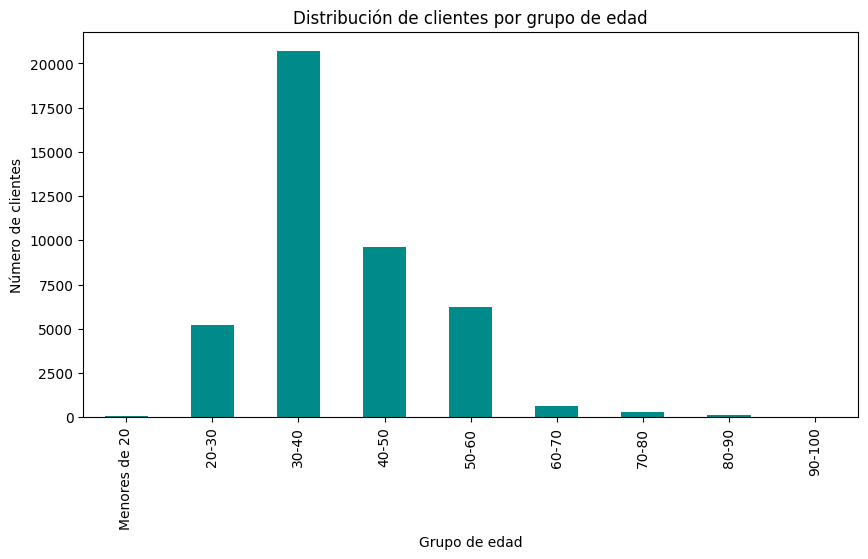

In [178]:
import matplotlib.pyplot as plt

bbdd_demografia["Grupo_Edad"].value_counts().sort_index().plot(kind="bar", figsize=(10,5),color="darkcyan")
plt.title("Distribución de clientes por grupo de edad")
plt.xlabel("Grupo de edad")
plt.ylabel("Número de clientes")
plt.show()


In [179]:
bbdd_demografia["Year_Sheet"].value_counts().sort_index()

Year_Sheet
2012    20115
2013     8965
2014    14090
Name: count, dtype: int64

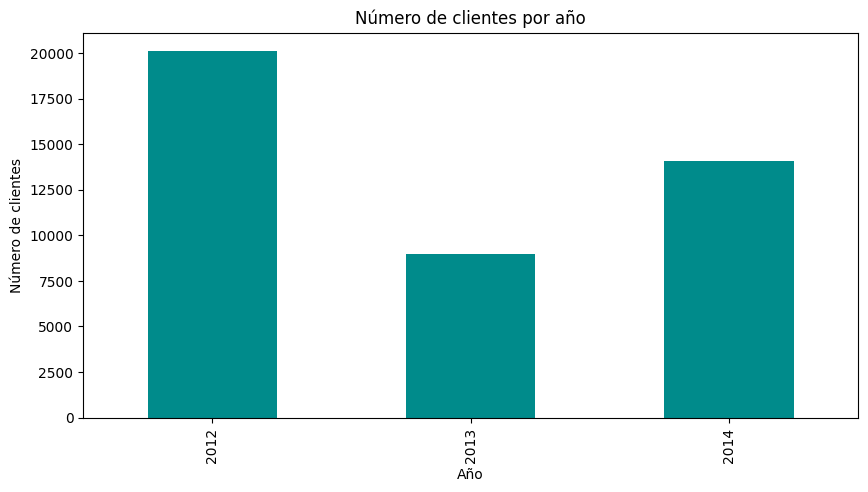

In [180]:
bbdd_demografia["Year_Sheet"].value_counts().sort_index().plot(kind="bar", figsize=(10,5),color="darkcyan")

plt.title("Número de clientes por año")
plt.xlabel("Año")
plt.ylabel("Número de clientes")
plt.show()

In [181]:
bbdd_demografia["job"].value_counts().sort_index()

job
admin.           11218
blue-collar       9654
entrepreneur      1522
housemaid         1123
management        3050
retired           1790
self-employed     1489
services          4162
student            903
technician        7026
unemployed        1063
Name: count, dtype: int64

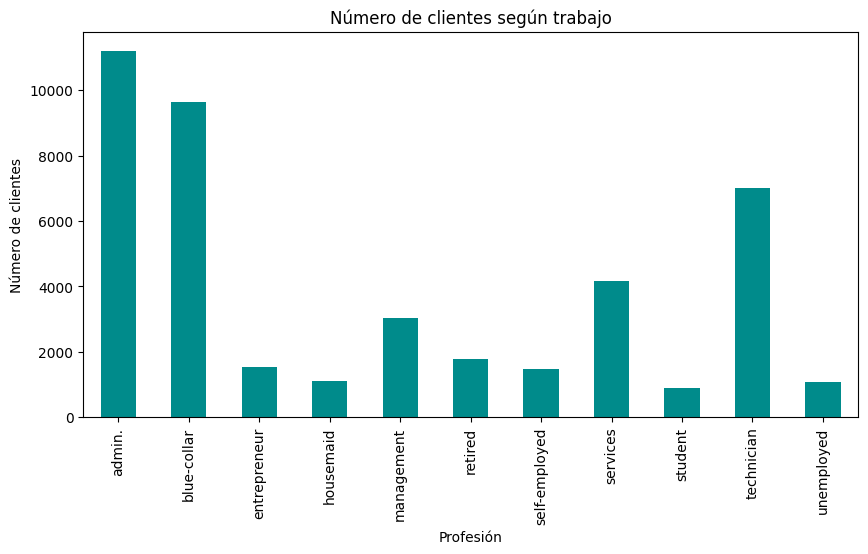

In [182]:
bbdd_demografia["job"].value_counts().sort_index().plot(kind="bar", figsize=(10,5),color="darkcyan")

plt.title("Número de clientes según trabajo")
plt.xlabel("Profesión")
plt.ylabel("Número de clientes")
plt.show()



In [183]:
bbdd_demografia["education"].value_counts().sort_index()

education
basic.4y                4356
basic.6y                2386
basic.9y                6309
high.school             9925
illiterate                18
professional.course     5477
university.degree      14529
Name: count, dtype: int64

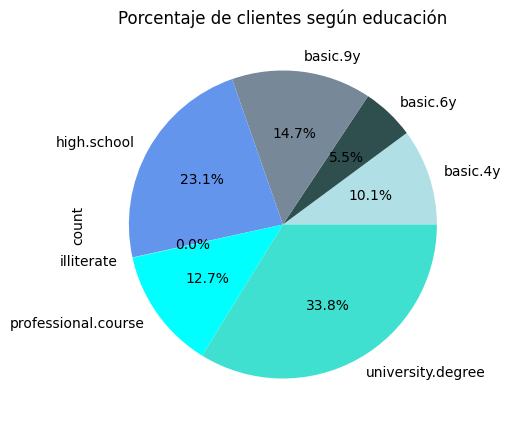

In [194]:
bbdd_demografia["education"].value_counts().sort_index().plot(kind="pie", figsize=(10,5),colors=["powderblue","Darkslategrey","lightslategrey", "cornflowerblue", "skyblue", "aqua", "turquoise"],autopct="%1.1f%%")

plt.title("Porcentaje de clientes según educación")
plt.show()

In [185]:
bbdd_demografia["loan"].value_counts().sort_index()

loan
0.0    36468
1.0     6532
Name: count, dtype: int64

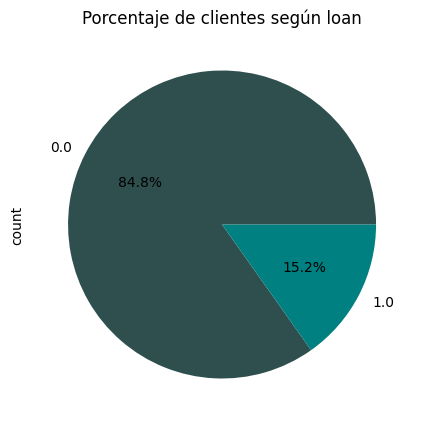

In [ ]:
bbdd_demografia["loan"].value_counts().sort_index().plot(kind="pie", figsize=(10,5),colors=["Darkslategrey", "teal"],autopct="%1.1f%%")

plt.title("Porcentaje de clientes según prestamos")
plt.show()

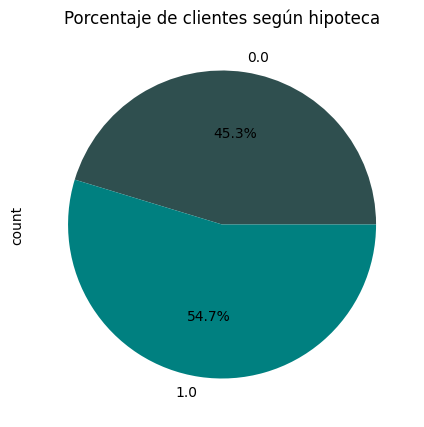

In [196]:
bbdd_demografia["housing"].value_counts().sort_index().plot(kind="pie", figsize=(10,5),colors=["Darkslategrey", "teal"],autopct="%1.1f%%")

plt.title("Porcentaje de clientes según hipoteca")
plt.show()

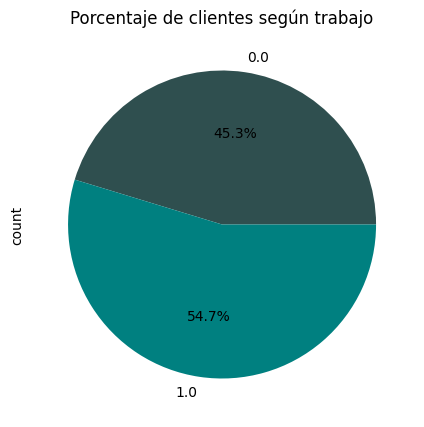

In [187]:
bbdd_demografia["housing"].value_counts().sort_index().plot(kind="pie", figsize=(10,5),colors=["Darkslategrey", "teal"],autopct="%1.1f%%")

plt.title("Porcentaje de clientes según trabajo")
plt.show()

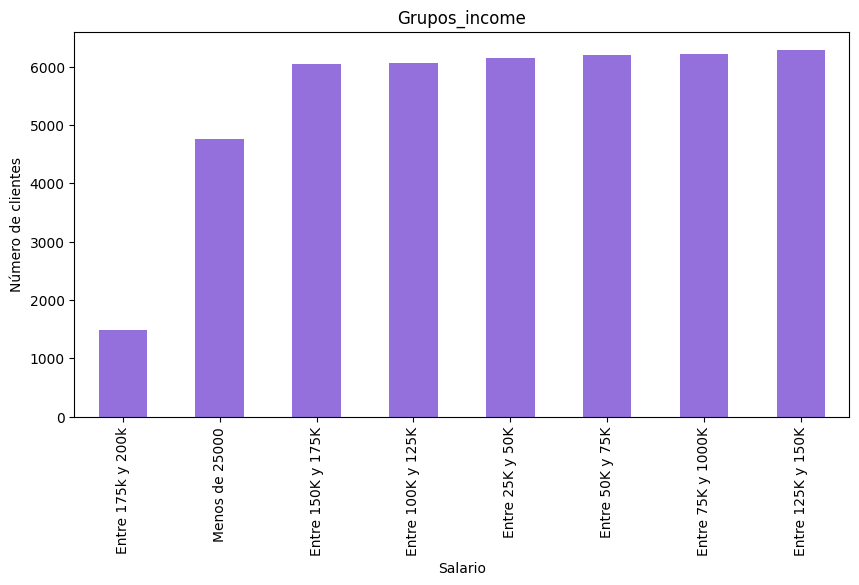

In [188]:
bbdd_demografia["Grupo_income"].value_counts().sort_values().plot(kind="bar",figsize=(10,5),color=["mediumpurple"])

plt.title("Grupos_income")
plt.xlabel("Salario")
plt.ylabel("Número de clientes")
plt.show()


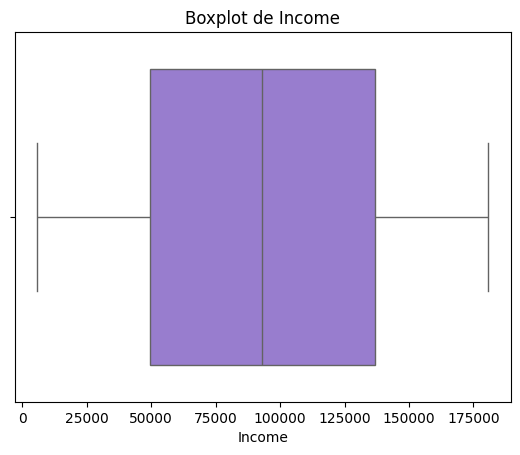

In [189]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.boxplot(data=bbdd_demografia, x="Income", color="mediumpurple")
plt.title("Boxplot de Income")
plt.show()

# No hay outliers en income 

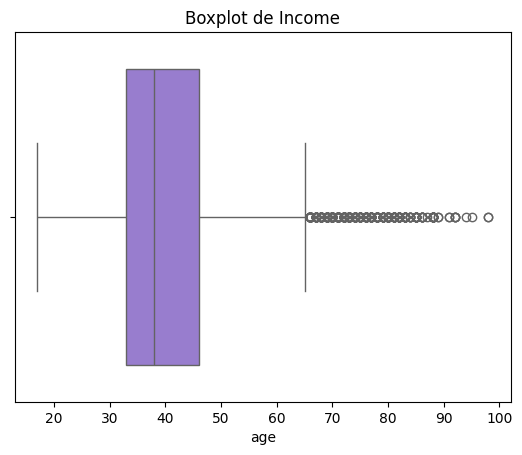

In [ ]:
sns.boxplot(data=bbdd_demografia, x="age", color="Mediumpurple")
plt.title("Boxplot de Income")
plt.show()

# Hay bastantes outliers, es decir, hay muchas personas 